### Which Pokémon have attack distributions that deviate furthest from their type's typical profile?
## This is a census study because it shows all the pokemon across all gens.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv("pokemon.csv")

In [11]:
stats = ['attack']

In [20]:
mean_attack = df.groupby('primary_type')['attack'].transform('mean')
std_attack = df.groupby('primary_type')['attack'].transform('std')

In [19]:
df['attack_z'] = (df['attack'] - mean_attack) / std_attack

In [21]:
outliers = df[df['attack_z'].abs() >= 2.5].sort_values(by='attack_z', ascending=False)
outliers[['english_name', 'primary_type', 'attack', 'attack_z']]

,english_name,primary_type,attack,attack_z
797,Kartana,grass,181,3.671713
288,Slaking,normal,160,3.000336
485,Regigigas,normal,160,3.000336
385,Deoxys,psychic,150,2.698855
1013,Okidogi,poison,128,2.634987
435,Bronzor,steel,24,-2.558071


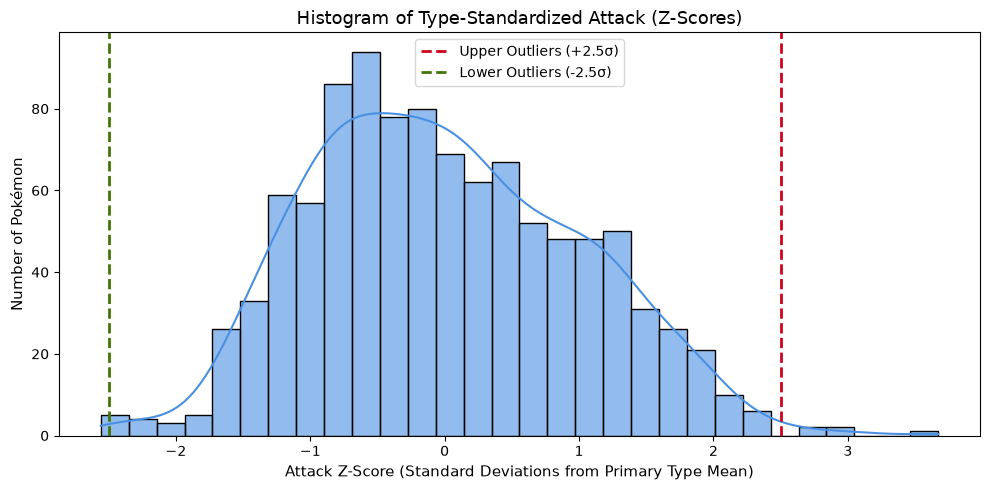

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x='attack_z',
    bins=30,
    kde=True,
    color='#4A90E2',
    edgecolor='black',
    alpha=0.6
)
plt.axvline(2.5, color='#D0021B', linestyle='--', linewidth=2, label='Upper Outliers (+2.5σ)')
plt.axvline(-2.5, color='#417505', linestyle='--', linewidth=2, label='Lower Outliers (-2.5σ)')
plt.title('Histogram of Type-Standardized Attack (Z-Scores)', fontsize=13)
plt.xlabel('Attack Z-Score (Standard Deviations from Primary Type Mean)', fontsize=11)
plt.ylabel('Number of Pokémon', fontsize=11)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

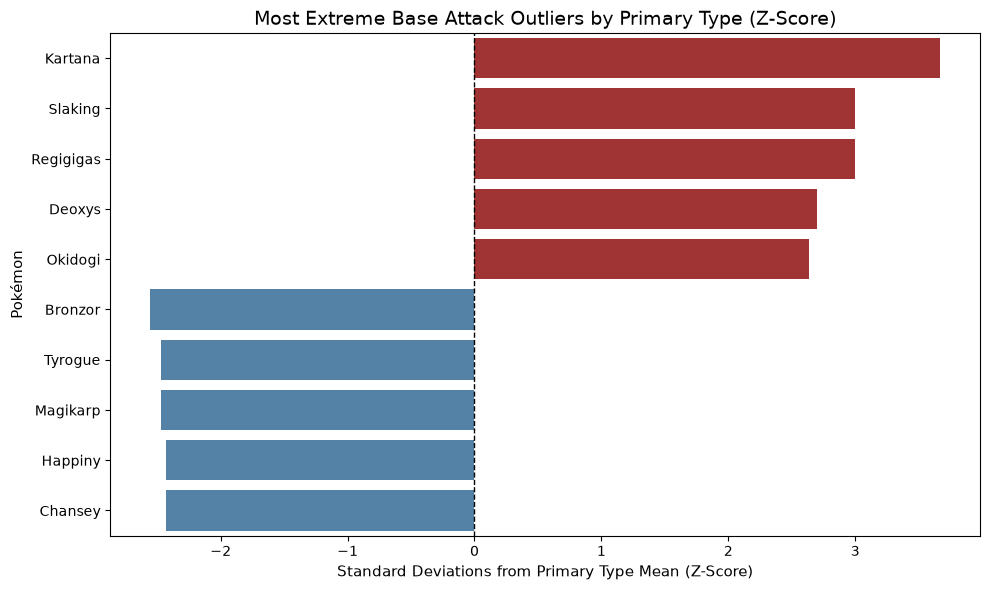

In [25]:
top_attackers = df.sort_values(by='attack_z', ascending=False).head(5)
bottom_attackers = df.sort_values(by='attack_z', ascending=True).head(5)
extremes = pd.concat([top_attackers, bottom_attackers])

plt.figure(figsize=(10, 6))
colors = ['firebrick' if z > 0 else 'steelblue' for z in extremes['attack_z']]

sns.barplot(
    data=extremes,
    x='attack_z',
    y='english_name',
    hue='english_name',
    palette=colors,
    legend=False
)
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.title('Most Extreme Base Attack Outliers by Primary Type (Z-Score)', fontsize=14)
plt.xlabel('Standard Deviations from Primary Type Mean (Z-Score)', fontsize=11)
plt.ylabel('Pokémon', fontsize=11)
plt.tight_layout()
plt.show()

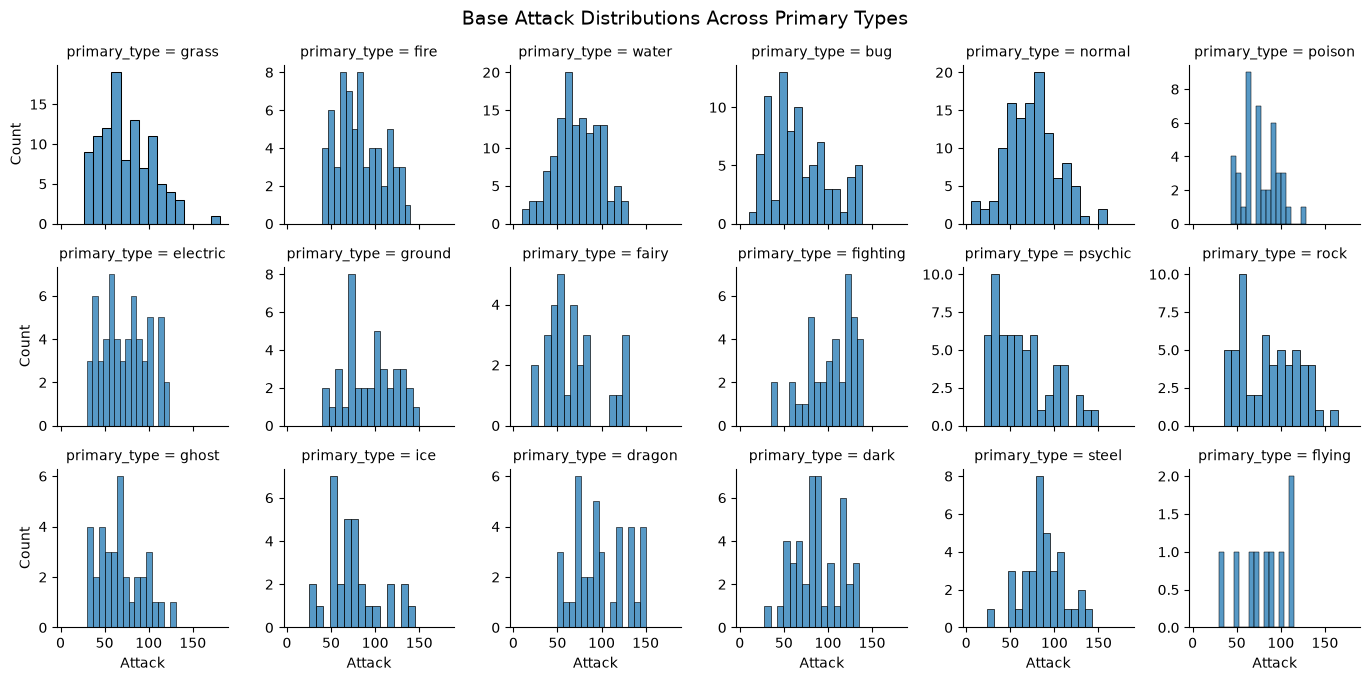

In [27]:
g = sns.FacetGrid(
    data=df,
    col='primary_type',
    col_wrap=6,
    height=2.3,
    sharey=False
)
g.map(
    sns.histplot,
    'attack',
    bins=15,
    color='#1F77B4',
    edgecolor='black'
)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Base Attack Distributions Across Primary Types', fontsize=14)
g.set_axis_labels('Attack', 'Count')
plt.tight_layout()
plt.show()

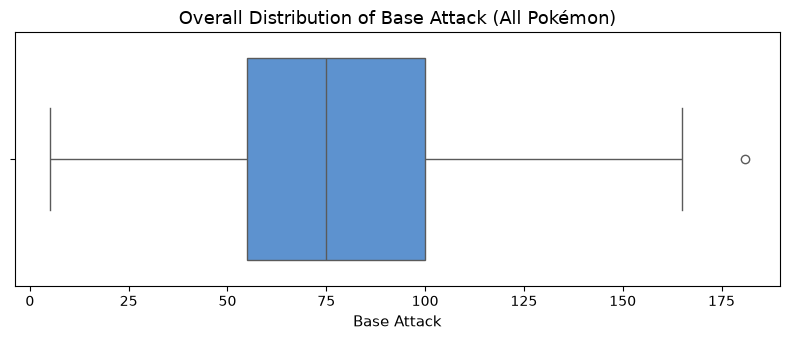

In [31]:
plt.figure(figsize=(8, 3.5))
sns.boxplot(x=df['attack'], color='#4A90E2')
plt.title('Overall Distribution of Base Attack (All Pokémon)', fontsize=13)
plt.xlabel('Base Attack', fontsize=11)
plt.tight_layout()
plt.show()


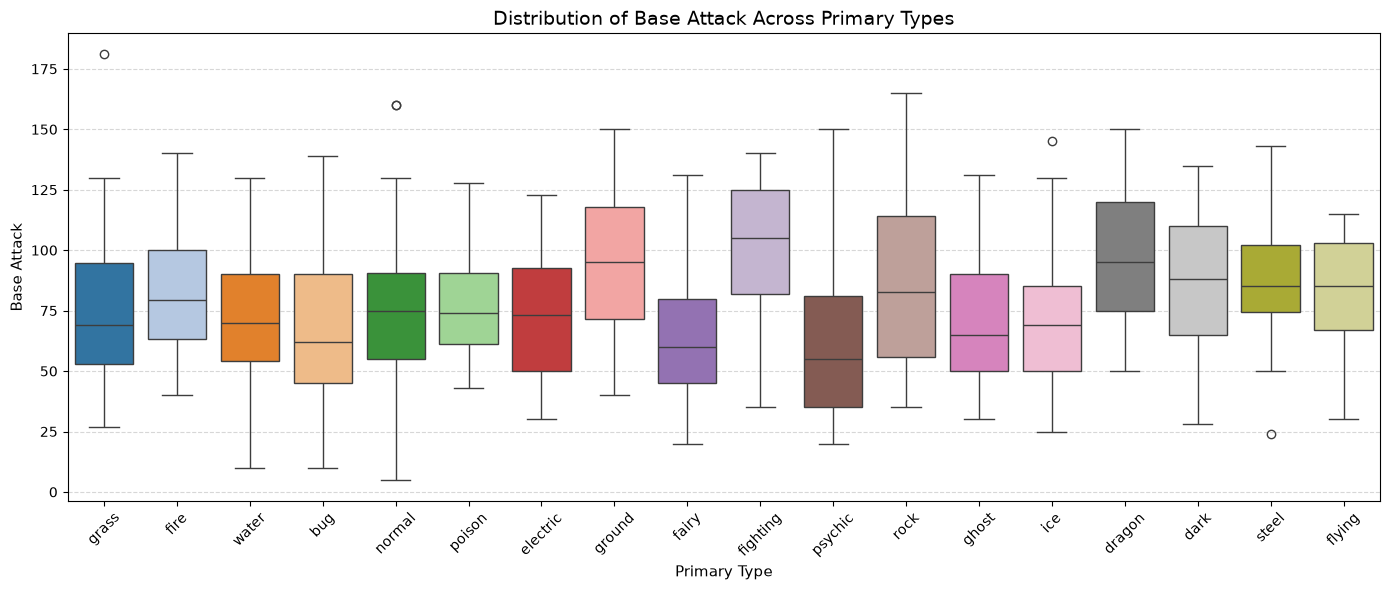

In [33]:
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df, 
    x='primary_type', 
    y='attack', 
    hue='primary_type', 
    palette='tab20', 
    legend=False
)
plt.title('Distribution of Base Attack Across Primary Types', fontsize=14)
plt.xlabel('Primary Type', fontsize=11)
plt.ylabel('Base Attack', fontsize=11)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Conclusion

##### Pokémon such as Kartana, Slaking, and Deoxys (Attack Forme) are the most deviating examples from the behavior expected of their type based on the base attack; they are the most physical outliers of all the data set and lie far outside the IQR. Given that our graph shows skewness and outliers, it is better to use IQR than the standard deviation to measure the spread of the data set because skewness and outliers do not affect IQR.